필요한거 import 

In [1]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import koreanize_matplotlib

# 한글 폰트 에러나서 변경
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', 100)
# pd.set_option('display.width', 1200)

# sns.set_theme()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1200)

# -------------------------
# 한글 폰트 설정
# -------------------------

font_path = r'C:\Windows\Fonts\malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

print('사용 폰트:', font_name)

# seaborn 기본 설정
sns.set_theme(
    style='whitegrid',
    font=font_name
)

# seaborn 설정 이후 matplotlib 폰트 재지정
plt.rcParams['font.family'] = font_name
plt.rcParams['font.sans-serif'] = [font_name]
plt.rcParams['axes.unicode_minus'] = False

print('font.family:', plt.rcParams['font.family'])
print('font.sans-serif:', plt.rcParams['font.sans-serif'])

사용 폰트: Malgun Gothic
font.family: ['Malgun Gothic']
font.sans-serif: ['Malgun Gothic']


데이터 로드 및 점검

In [2]:
data_path = r'data\processed\analysis_dataset.csv'

df = pd.read_csv(
    data_path,
    encoding='utf-8-sig'
)

df['날짜'] = pd.to_datetime(df['날짜'])

print('데이터 크기:', df.shape)
print('\n컬럼:')
print(df.columns.tolist())

print('\n데이터 타입:')
print(df.dtypes)

print('\n결측치:')
print(df.isna().sum())

데이터 크기: (2196, 9)

컬럼:
['날짜', '시간대', '따릉이대여건수', '지하철승차인원', '기온(°C)', '요일', '요일명', '주말여부', '공휴일여부']

데이터 타입:
날짜         datetime64[us]
시간대                   str
따릉이대여건수             int64
지하철승차인원           float64
기온(°C)            float64
요일                  int64
요일명                   str
주말여부                 bool
공휴일여부                bool
dtype: object

결측치:
날짜         0
시간대        0
따릉이대여건수    0
지하철승차인원    0
기온(°C)     0
요일         0
요일명        0
주말여부       0
공휴일여부      0
dtype: int64


구조 확인

In [3]:
print('===== 날짜 범위 =====')
print(df['날짜'].min())
print(df['날짜'].max())

print('\n===== 시간대 =====')
print(df['시간대'].unique())

print('\n===== 요일 =====')
print(df['요일명'].value_counts())

print('\n===== 주말 =====')
print(df['주말여부'].value_counts())

print('\n===== 공휴일 =====')
print(df['공휴일여부'].value_counts())

===== 날짜 범위 =====
2025-03-01 00:00:00
2025-12-31 00:00:00

===== 시간대 =====
<StringArray>
['06-07', '07-08', '08-09', '09-10', '10-11', '11-12', '12-13', '13-14', '14-15', '15-16', '16-17', '17-18', '18-19', '19-20', '20-21', '21-22', '22-23', '23-24']
Length: 18, dtype: str

===== 요일 =====
요일명
월    360
일    324
화    324
토    306
수    306
목    288
금    288
Name: count, dtype: int64

===== 주말 =====
주말여부
False    1566
True      630
Name: count, dtype: int64

===== 공휴일 =====
공휴일여부
False    2106
True       90
Name: count, dtype: int64


key 중복 (날짜, 시간대 중복 체크)

In [4]:
key = ['날짜', '시간대']

print('\n===== 중복 key =====')
print(df.duplicated(key).sum())


===== 중복 key =====
0


평일+비공휴일에 대해서 처리 (이후는 여유 있으면)

In [5]:
analysis_df = df[
    (~df['주말여부']) &
    (~df['공휴일여부'])
].copy()

analysis_df = analysis_df.reset_index(drop=True)

print('전체 데이터:', len(df))
print('평일·비공휴일:', len(analysis_df))

전체 데이터: 2196
평일·비공휴일: 1494


월, 월명 추가해서 사용

In [6]:
month_name = {
    3: '3월',
    6: '6월',
    9: '9월',
    12: '12월'
}

analysis_df['월'] = analysis_df['날짜'].dt.month
analysis_df['월명'] = analysis_df['월'].map(month_name)

# 주요 지표들 통계값 (중요)

In [7]:
stats = analysis_df[
    ['기온(°C)', '따릉이대여건수', '지하철승차인원']
].describe()

stats

,기온(°C),따릉이대여건수,지하철승차인원
count,1494.000000,1494.000000,1494.000000
mean,14.674096,5933.419009,281945.211513
std,10.960095,3815.027594,132248.287337
min,-11.800000,102.000000,51115.000000
25%,4.400000,3391.250000,199355.500000
50%,17.900000,4964.500000,237287.000000
75%,24.000000,7695.750000,329742.000000
max,33.600000,19943.000000,632005.000000


왜도 확인 (데이터가 어느 방향에 몰려있는지)
- 평균과 중앙값 차이
- 극단값
- 분포 비대칭
- 정규화/로그변환 필요성

- # 둘 다 이용량이 출/퇴근 시간대에 집중된 형태

In [8]:
skewness = analysis_df[
    ['기온(°C)', '따릉이대여건수', '지하철승차인원']
].skew()

print('왜도:')
print(skewness)

왜도:
기온(°C)    -0.266867
따릉이대여건수    1.137745
지하철승차인원    0.889195
dtype: float64


기온 분포
- 특정 기온 구간에 해당되는 행 개수

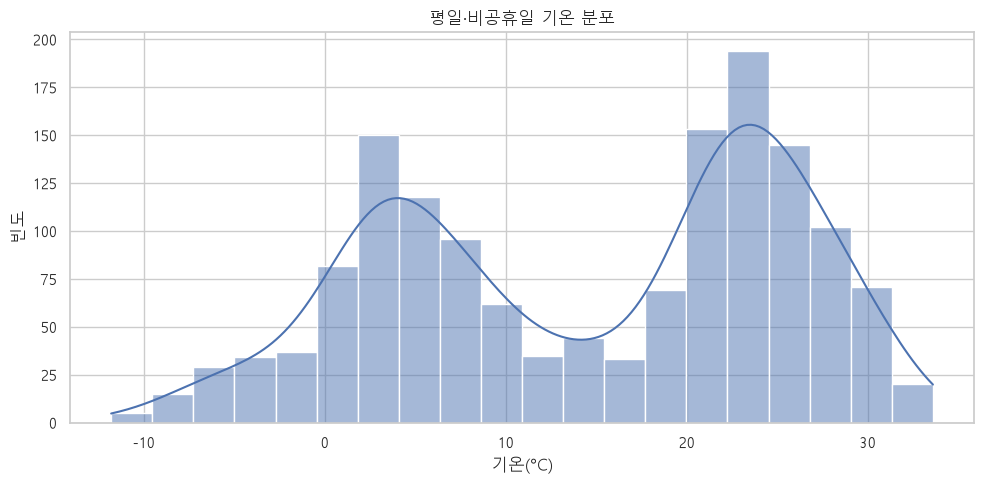

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=analysis_df,
    x='기온(°C)',
    bins=20,
    kde=True
)

plt.title('평일·비공휴일 기온 분포')
plt.xlabel('기온(°C)')
plt.ylabel('빈도')

plt.tight_layout()
plt.show()

따릉이 분포
- 특정 대여건수 구간에 해당되는 행 개수

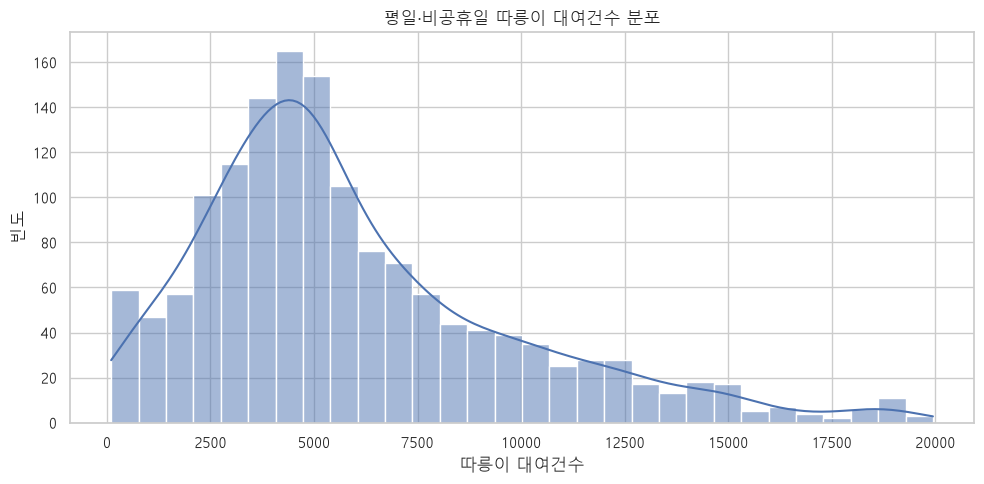

In [10]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=analysis_df,
    x='따릉이대여건수',
    bins=30,
    kde=True
)

plt.title('평일·비공휴일 따릉이 대여건수 분포')
plt.xlabel('따릉이 대여건수')
plt.ylabel('빈도')

plt.tight_layout()
plt.show()

지하철 분포
- 특정 승차건수 구간에 해당되는 행 개수

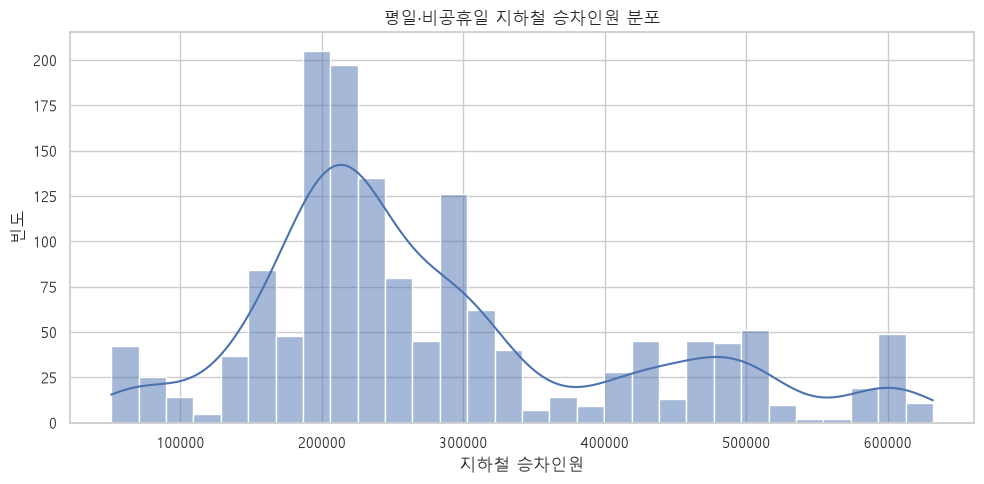

In [11]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=analysis_df,
    x='지하철승차인원',
    bins=30,
    kde=True
)

plt.title('평일·비공휴일 지하철 승차인원 분포')
plt.xlabel('지하철 승차인원')
plt.ylabel('빈도')

plt.tight_layout()
plt.show()

월별 기본 통계
- 3,6,9,12월 평균 기온과 대여건수, 승차건수

In [12]:
monthly = (
    analysis_df
    .groupby(['월', '월명'])
    .agg(
        평균기온=('기온(°C)', 'mean'),
        평균따릉이=('따릉이대여건수', 'mean'),
        평균지하철=('지하철승차인원', 'mean'),
        일수=('날짜', 'nunique')
    )
    .reset_index()
    .sort_values('월')
)

monthly

,월,월명,평균기온,평균따릉이,평균지하철,일수
0,3,3월,9.040833,5440.152778,283382.986111,20
1,6,6월,24.757895,7354.494152,278205.005848,19
2,9,9월,24.220202,7305.353535,280545.040404,22
3,12,12월,1.540404,3782.616162,285268.492424,22


월별 평균 기온

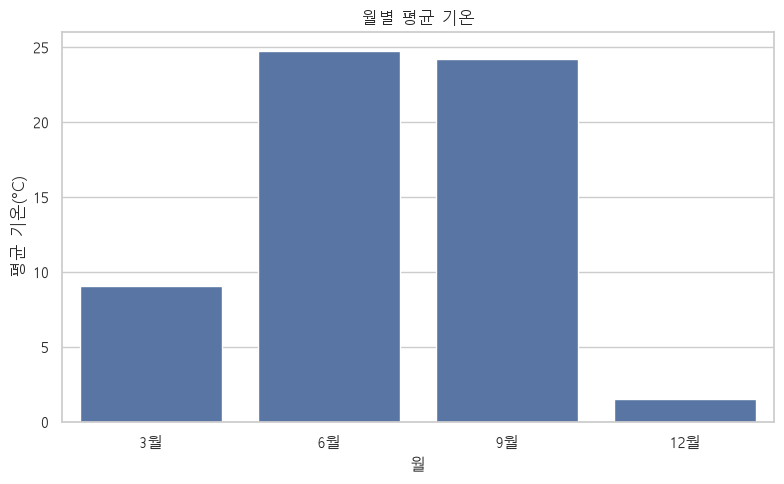

In [13]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=monthly,
    x='월명',
    y='평균기온'
)

plt.title('월별 평균 기온')
plt.xlabel('월')
plt.ylabel('평균 기온(°C)')

plt.tight_layout()
plt.show()

월별 평균 따릉이
 - 이걸 바로 기온으로 묶으면 절대 안됨

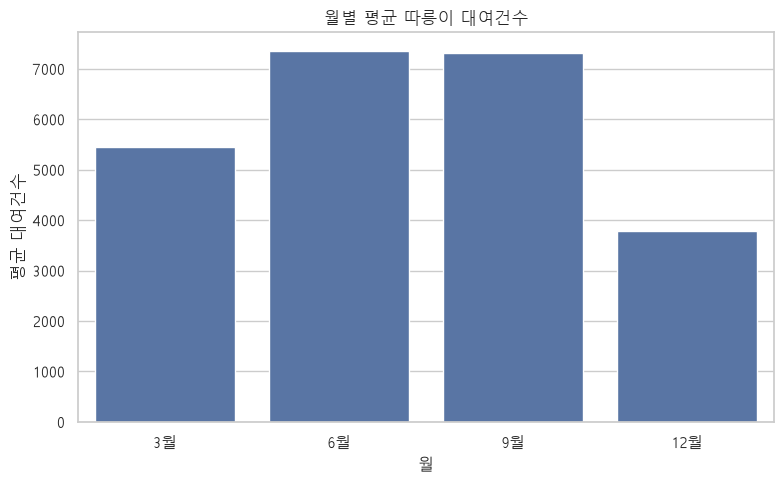

In [14]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=monthly,
    x='월명',
    y='평균따릉이'
)

plt.title('월별 평균 따릉이 대여건수')
plt.xlabel('월')
plt.ylabel('평균 대여건수')

plt.tight_layout()
plt.show()

월별 평균 지하철
- 이걸 바로 기온으로 묶으면 절대 안됨

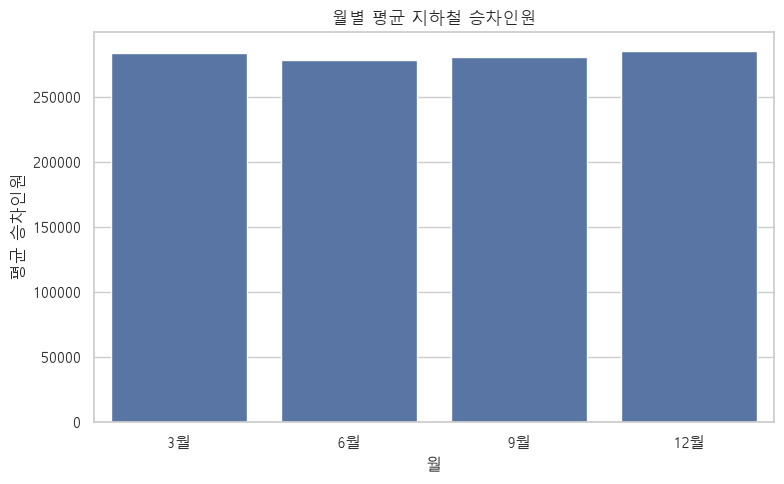

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=monthly,
    x='월명',
    y='평균지하철'
)

plt.title('월별 평균 지하철 승차인원')
plt.xlabel('월')
plt.ylabel('평균 승차인원')

plt.tight_layout()
plt.show()

시간대별 평균 이용량
- 아무래도 출퇴근 시간에 집중

In [16]:
hour_order = [
    '06-07', '07-08', '08-09', '09-10',
    '10-11', '11-12', '12-13', '13-14',
    '14-15', '15-16', '16-17', '17-18',
    '18-19', '19-20', '20-21', '21-22',
    '22-23', '23-24'
]

hourly = (
    analysis_df
    .groupby('시간대')
    .agg(
        평균따릉이=('따릉이대여건수', 'mean'),
        평균지하철=('지하철승차인원', 'mean')
    )
    .reindex(hour_order)
    .reset_index()
)

hourly

,시간대,평균따릉이,평균지하철
0,06-07,3192.819277,151077.506024
1,07-08,7889.686747,414058.228916
2,08-09,10904.879518,494632.253012
3,09-10,5210.542169,285343.759036
4,10-11,3542.578313,198217.530120
5,11-12,4053.867470,195427.963855
6,12-13,4230.421687,211058.192771
7,13-14,4073.566265,218959.650602
8,14-15,4142.301205,230050.373494
9,15-16,4885.469880,270526.036145


시간대별 따릉이 평균 이용량
- 출퇴근 시간에 얼마나 극단적인지 확인

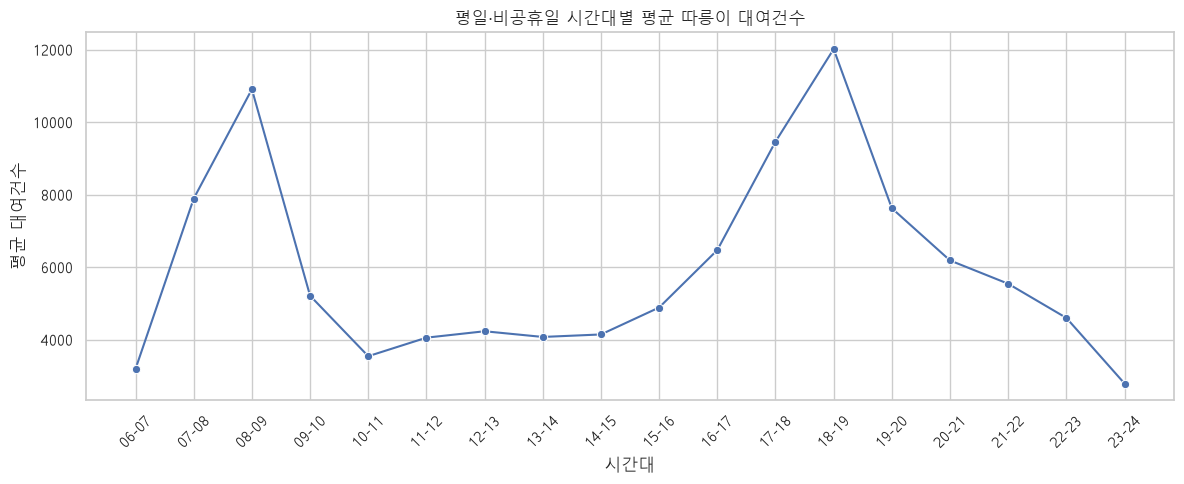

In [17]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly,
    x='시간대',
    y='평균따릉이',
    marker='o'
)

plt.title('평일·비공휴일 시간대별 평균 따릉이 대여건수')
plt.xlabel('시간대')
plt.ylabel('평균 대여건수')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

시간대별 지하철 평균 이용량

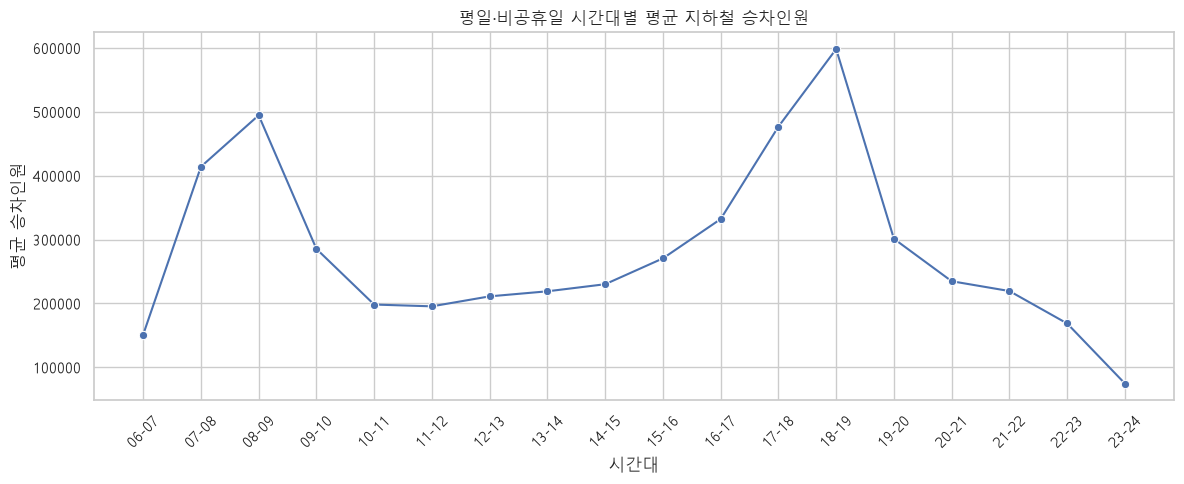

In [18]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly,
    x='시간대',
    y='평균지하철',
    marker='o'
)

plt.title('평일·비공휴일 시간대별 평균 지하철 승차인원')
plt.xlabel('시간대')
plt.ylabel('평균 승차인원')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

시간대별 따릉이 지하철을 패턴을 정규화
- 평균=100 지수 만든다? 뭔말인지 찾아봐야겠음

In [19]:
hourly['따릉이지수'] = (
    hourly['평균따릉이'] /
    hourly['평균따릉이'].mean()
    * 100
)

hourly['지하철지수'] = (
    hourly['평균지하철'] /
    hourly['평균지하철'].mean()
    * 100
)

hourly

,시간대,평균따릉이,평균지하철,따릉이지수,지하철지수
0,06-07,3192.819277,151077.506024,53.810784,53.583994
1,07-08,7889.686747,414058.228916,132.970328,146.857691
2,08-09,10904.879518,494632.253012,183.787450,175.435593
3,09-10,5210.542169,285343.759036,87.816858,101.205393
4,10-11,3542.578313,198217.530120,59.705514,70.303563
5,11-12,4053.867470,195427.963855,68.322622,69.314163
6,12-13,4230.421687,211058.192771,71.298212,74.857875
7,13-14,4073.566265,218959.650602,68.654620,77.660354
8,14-15,4142.301205,230050.373494,69.813057,81.593999
9,15-16,4885.469880,270526.036145,82.338191,95.949860


따릉이 지하철 평균 대비 특정 시간대 이용량이 얼마나 다른지
- 아마 이게 스트림릿에 올라갈듯?

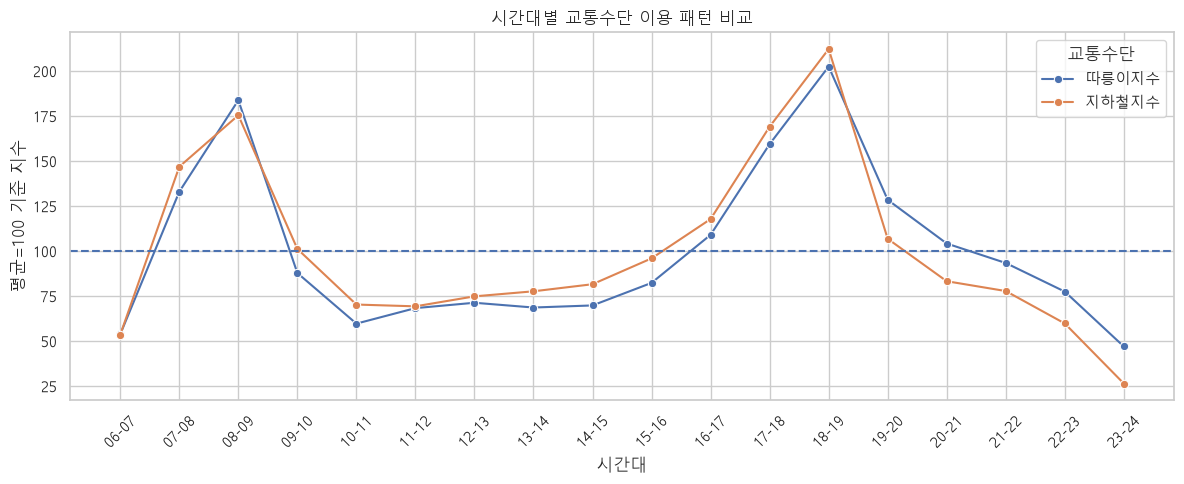

In [20]:
hourly_index = hourly.melt(
    id_vars='시간대',
    value_vars=['따릉이지수', '지하철지수'],
    var_name='교통수단',
    value_name='지수'
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_index,
    x='시간대',
    y='지수',
    hue='교통수단',
    marker='o'
)

plt.axhline(100, linestyle='--')

plt.title('시간대별 교통수단 이용 패턴 비교')
plt.xlabel('시간대')
plt.ylabel('평균=100 기준 지수')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

앞서서는 평일(주말,공휴일 제외) 했는데 이번엔 월~금

In [21]:
weekday_order = ['월', '화', '수', '목', '금']

weekday = (
    analysis_df
    .groupby('요일명')
    .agg(
        평균따릉이=('따릉이대여건수', 'mean'),
        평균지하철=('지하철승차인원', 'mean')
    )
    .reindex(weekday_order)
    .reset_index()
)

weekday

,요일명,평균따릉이,평균지하철
0,월,6452.160819,272911.435673
1,화,5880.676471,279832.045752
2,수,5573.336601,281437.666667
3,목,6524.755556,286507.111111
4,금,5152.877778,291796.233333


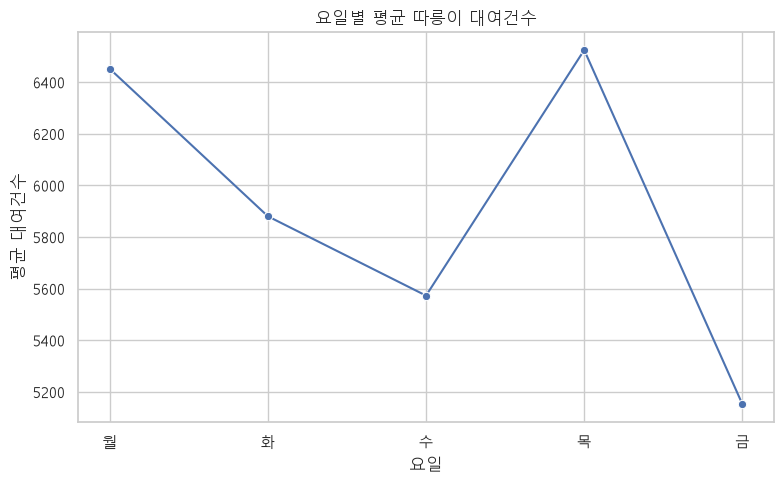

In [22]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=weekday,
    x='요일명',
    y='평균따릉이',
    marker='o'
)

plt.title('요일별 평균 따릉이 대여건수')
plt.xlabel('요일')
plt.ylabel('평균 대여건수')

plt.tight_layout()
plt.show()

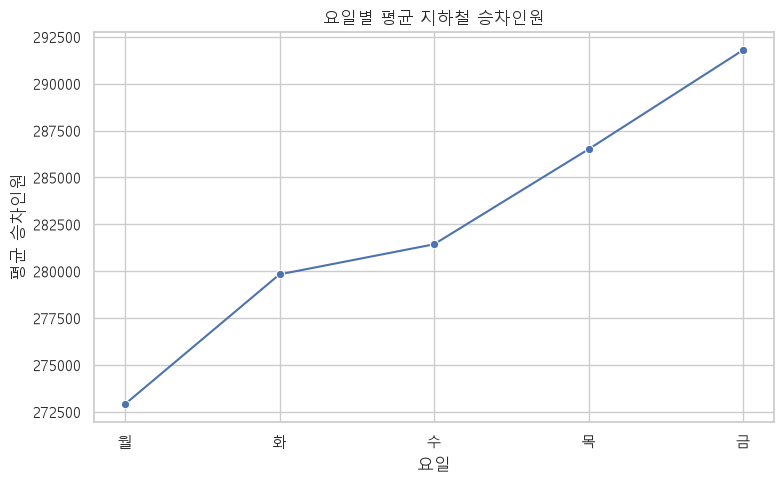

In [23]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=weekday,
    x='요일명',
    y='평균지하철',
    marker='o'
)

plt.title('요일별 평균 지하철 승차인원')
plt.xlabel('요일')
plt.ylabel('평균 승차인원')

plt.tight_layout()
plt.show()

상관계수 : pearson + Spearman
- 여기부터 진짜 뭔소린지 모르겠음; 선형관계랑 단조로운 관계라는데 

In [24]:
target_cols = [
    '기온(°C)',
    '따릉이대여건수',
    '지하철승차인원'
]

print('===== Pearson =====')
print(
    analysis_df[target_cols]
    .corr(method='pearson')
)

print('\n===== Spearman =====')
print(
    analysis_df[target_cols]
    .corr(method='spearman')
)

===== Pearson =====
           기온(°C)   따릉이대여건수   지하철승차인원
기온(°C)   1.000000  0.423440  0.012718
따릉이대여건수  0.423440  1.000000  0.652512
지하철승차인원  0.012718  0.652512  1.000000

===== Spearman =====
           기온(°C)   따릉이대여건수   지하철승차인원
기온(°C)   1.000000  0.462517  0.015601
따릉이대여건수  0.462517  1.000000  0.572017
지하철승차인원  0.015601  0.572017  1.000000


상관관계 히트맵
- 이건 ead용?

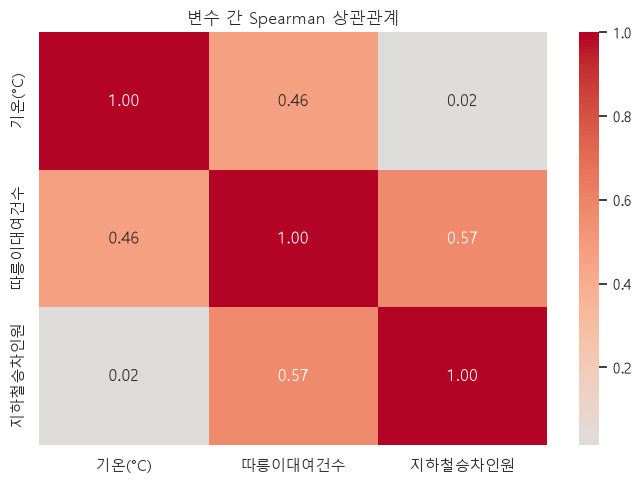

In [25]:
corr = analysis_df[target_cols].corr(method='spearman')

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('변수 간 Spearman 상관관계')
plt.tight_layout()
plt.show()

전체 기온 vs 따릉이
- 이걸 어떻게 vs 한다는거지

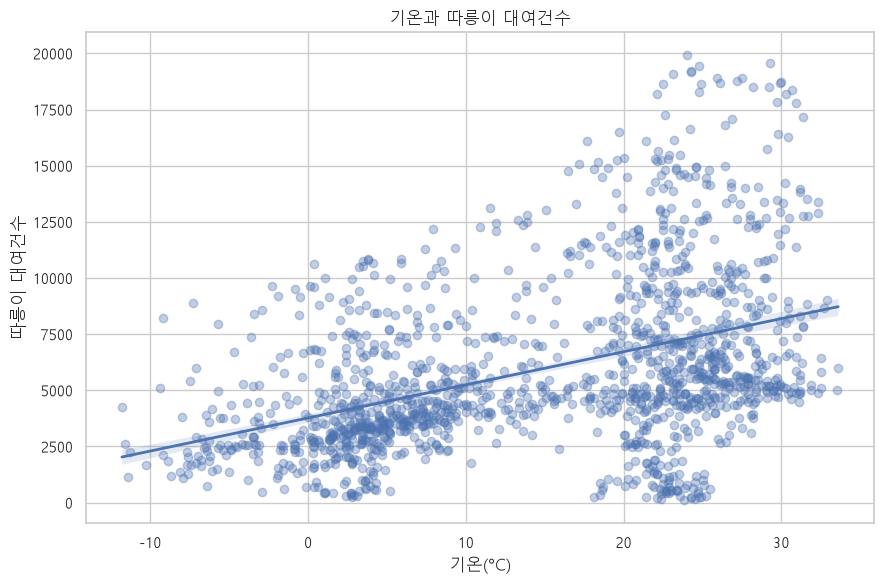

In [26]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=analysis_df,
    x='기온(°C)',
    y='따릉이대여건수',
    scatter_kws={'alpha': 0.35},
    line_kws={'linewidth': 2}
)

plt.title('기온과 따릉이 대여건수')
plt.xlabel('기온(°C)')
plt.ylabel('따릉이 대여건수')

plt.tight_layout()
plt.show()

전체 기온 vs 지하철

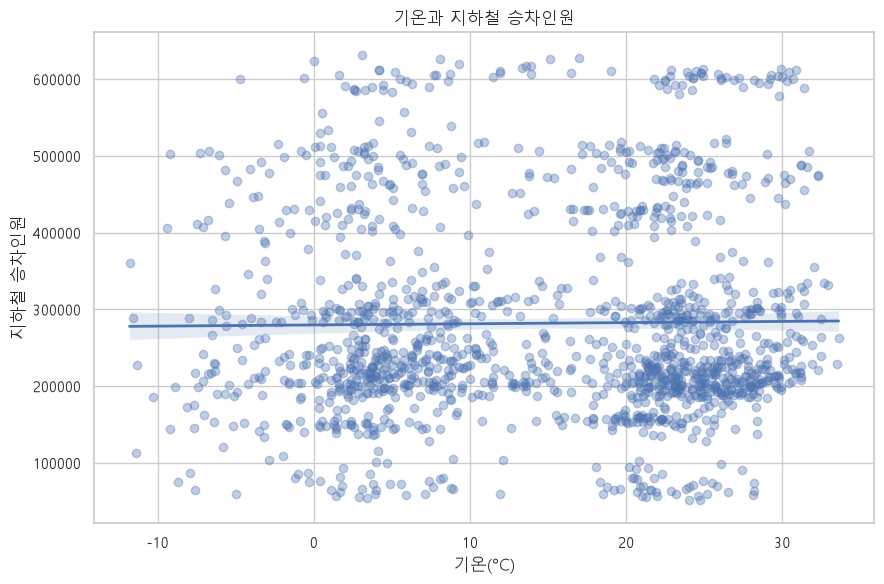

In [27]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=analysis_df,
    x='기온(°C)',
    y='지하철승차인원',
    scatter_kws={'alpha': 0.35},
    line_kws={'linewidth': 2}
)

plt.title('기온과 지하철 승차인원')
plt.xlabel('기온(°C)')
plt.ylabel('지하철 승차인원')

plt.tight_layout()
plt.show()

# 월별로 기온 관계 보기
- 3,12 / 6,9 묶어서 보라는데

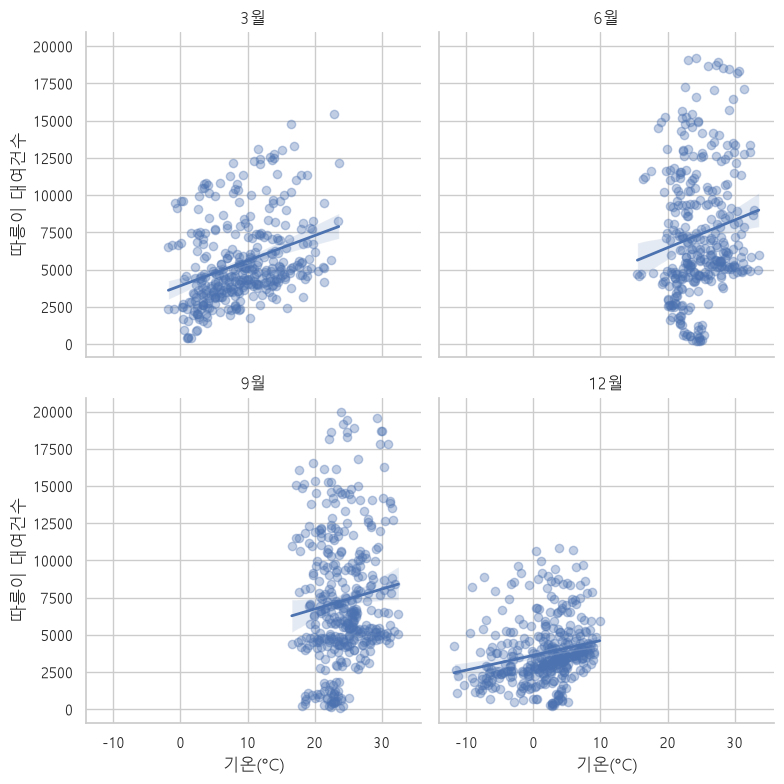

In [28]:
g = sns.lmplot(
    data=analysis_df,
    x='기온(°C)',
    y='따릉이대여건수',
    col='월명',
    col_order=['3월', '6월', '9월', '12월'],
    col_wrap=2,
    height=4,
    scatter_kws={'alpha': 0.35},
    line_kws={'linewidth': 2}
)

g.set_axis_labels('기온(°C)', '따릉이 대여건수')
g.set_titles('{col_name}')

plt.show()

# 핵심 : 시간대를 통제해서 기온 관계
- 시간이 같으면 이용 패턴이 같을텐데 여기서 달라지는건 기온 (물론 그 외에 날씨나 천재지변 등의 요인도 있음)
- 이 상관관계 값이 뚝 떨어진다 > 기온과 관계가 낮고, 이용량은 거진 시간대 영향이 엄청 큰것?

In [29]:
within_hour = analysis_df.copy()

within_hour['기온편차'] = (
    within_hour['기온(°C)']
    - within_hour.groupby('시간대')['기온(°C)'].transform('mean')
)

within_hour['따릉이편차'] = (
    within_hour['따릉이대여건수']
    - within_hour.groupby('시간대')['따릉이대여건수'].transform('mean')
)

within_hour['지하철편차'] = (
    within_hour['지하철승차인원']
    - within_hour.groupby('시간대')['지하철승차인원'].transform('mean')
)

In [30]:
print('===== 시간대 평균 제거 후 Pearson =====')

print(
    within_hour[
        ['기온편차', '따릉이편차', '지하철편차']
    ].corr(method='pearson')
)

print('\n===== 시간대 평균 제거 후 Spearman =====')

print(
    within_hour[
        ['기온편차', '따릉이편차', '지하철편차']
    ].corr(method='spearman')
)

===== 시간대 평균 제거 후 Pearson =====
           기온편차     따릉이편차     지하철편차
기온편차   1.000000  0.584147 -0.086010
따릉이편차  0.584147  1.000000  0.066015
지하철편차 -0.086010  0.066015  1.000000

===== 시간대 평균 제거 후 Spearman =====
           기온편차     따릉이편차     지하철편차
기온편차   1.000000  0.680278 -0.132751
따릉이편차  0.680278  1.000000  0.026602
지하철편차 -0.132751  0.026602  1.000000


# 특정 시간대에 기온관계가 강하게 나타나는지 확인
- 시간대별로 따릉이/지하철 기온 민감도 확인

In [31]:
hour_corr = []

for hour, group in analysis_df.groupby('시간대', sort=False):
    hour_corr.append({
        '시간대': hour,
        '따릉이_Pearson': group['기온(°C)'].corr(
            group['따릉이대여건수'],
            method='pearson'
        ),
        '따릉이_Spearman': group['기온(°C)'].corr(
            group['따릉이대여건수'],
            method='spearman'
        ),
        '지하철_Pearson': group['기온(°C)'].corr(
            group['지하철승차인원'],
            method='pearson'
        ),
        '지하철_Spearman': group['기온(°C)'].corr(
            group['지하철승차인원'],
            method='spearman'
        ),
        '관측수': len(group)
    })

hour_corr = pd.DataFrame(hour_corr)

hour_corr

,시간대,따릉이_Pearson,따릉이_Spearman,지하철_Pearson,지하철_Spearman,관측수
0,06-07,0.650159,0.606754,0.629567,0.594331,83
1,07-08,0.629655,0.563861,0.406385,0.255571,83
2,08-09,0.529246,0.538705,0.209253,-0.049627,83
3,09-10,0.576198,0.590084,0.120794,-0.141302,83
4,10-11,0.602590,0.653206,-0.232470,-0.233819,83
5,11-12,0.634859,0.687955,-0.362898,-0.316978,83
6,12-13,0.640495,0.693469,-0.309155,-0.270146,83
7,13-14,0.547012,0.616343,-0.341086,-0.299822,83
8,14-15,0.517308,0.623771,-0.393030,-0.333001,83
9,15-16,0.580662,0.680676,-0.355340,-0.317025,83


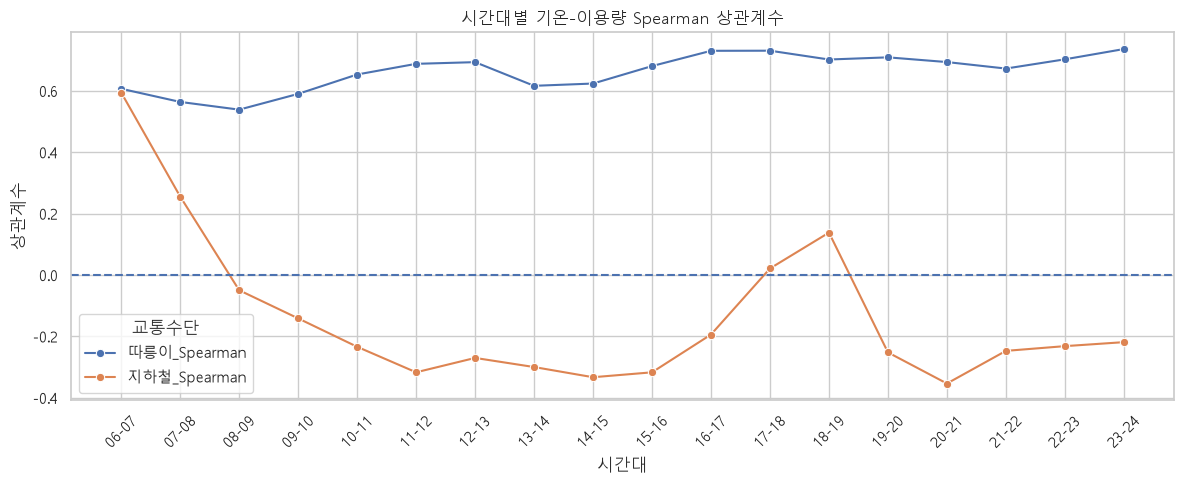

In [32]:
hour_corr_long = hour_corr.melt(
    id_vars=['시간대', '관측수'],
    value_vars=[
        '따릉이_Spearman',
        '지하철_Spearman'
    ],
    var_name='교통수단',
    value_name='상관계수'
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hour_corr_long,
    x='시간대',
    y='상관계수',
    hue='교통수단',
    marker='o'
)

plt.axhline(0, linestyle='--')

plt.title('시간대별 기온-이용량 Spearman 상관계수')
plt.xlabel('시간대')
plt.ylabel('상관계수')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 그래서 특정 온도부터 따릉이 급증하거나 급락?
- 5도 단위로 구간화 (0도 미만~30도이상)

In [33]:
bins = [
    -np.inf,
    0,
    5,
    10,
    15,
    20,
    25,
    30,
    np.inf
]

labels = [
    '0℃ 미만',
    '0~5℃',
    '5~10℃',
    '10~15℃',
    '15~20℃',
    '20~25℃',
    '25~30℃',
    '30℃ 이상'
]

analysis_df['기온구간_탐색'] = pd.cut(
    analysis_df['기온(°C)'],
    bins=bins,
    labels=labels,
    right=False
)

In [34]:
temp_summary = (
    analysis_df
    .groupby('기온구간_탐색', observed=False)
    .agg(
        평균기온=('기온(°C)', 'mean'),
        평균따릉이=('따릉이대여건수', 'mean'),
        평균지하철=('지하철승차인원', 'mean'),
        관측수=('기온(°C)', 'size')
    )
    .reset_index()
)

temp_summary

,기온구간_탐색,평균기온,평균따릉이,평균지하철,관측수
0,0℃ 미만,-4.214961,3382.149606,273449.984252,127
1,0~5℃,2.746377,3872.909420,280094.061594,276
2,5~10℃,7.204950,4891.599010,286759.183168,202
3,10~15℃,12.403125,6129.177083,296752.770833,96
4,15~20℃,18.054630,7332.101852,293804.129630,108
5,20~25℃,22.609424,6770.853403,276603.607330,382
6,25~30℃,27.191463,7725.211382,268614.487805,246
7,30℃ 이상,31.201754,8961.982456,338698.736842,57


따릉이 기온 구간별 이용량 그래프
- 관측수가 중요 

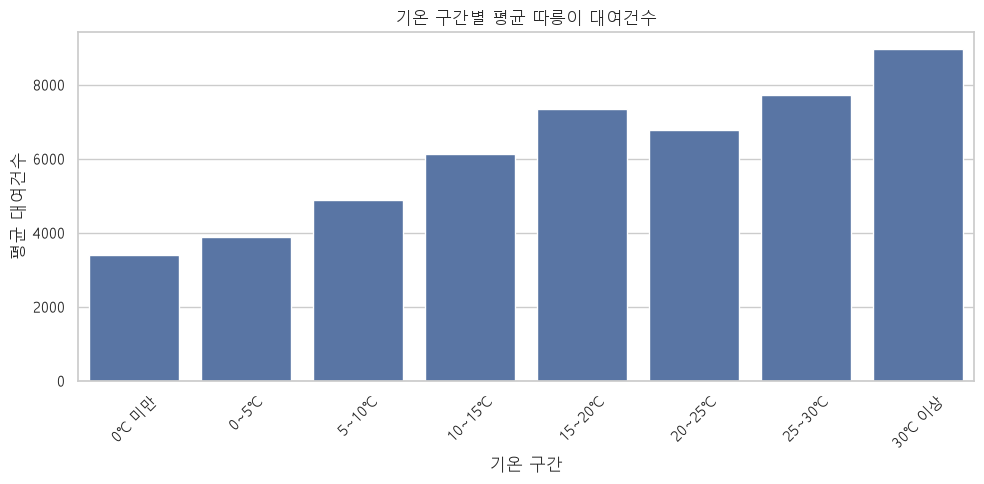

In [35]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=temp_summary,
    x='기온구간_탐색',
    y='평균따릉이'
)

plt.title('기온 구간별 평균 따릉이 대여건수')
plt.xlabel('기온 구간')
plt.ylabel('평균 대여건수')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

지하철 기온 구간별 이용량 그래프

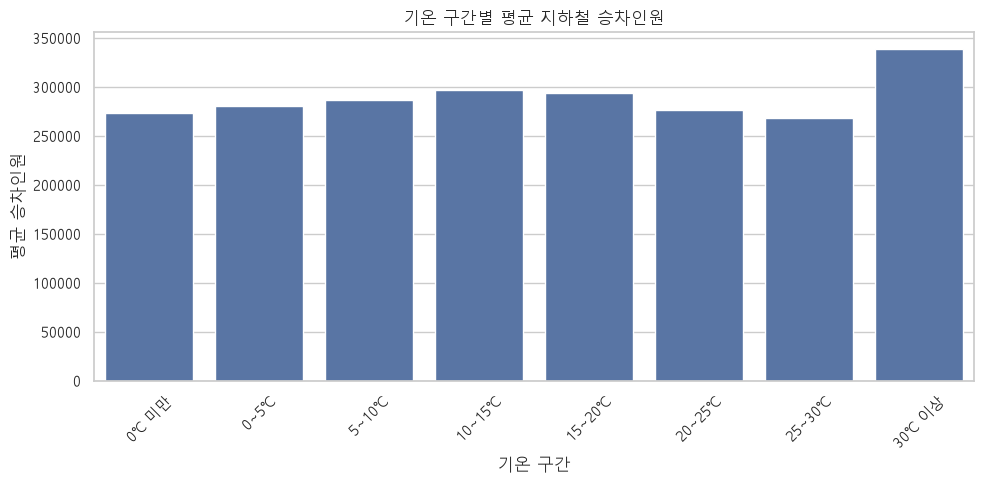

In [36]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=temp_summary,
    x='기온구간_탐색',
    y='평균지하철'
)

plt.title('기온 구간별 평균 지하철 승차인원')
plt.xlabel('기온 구간')
plt.ylabel('평균 승차인원')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

기온 구간별 "상대지수"

In [37]:
overall_bicycle_mean = analysis_df['따릉이대여건수'].mean()
overall_subway_mean = analysis_df['지하철승차인원'].mean()

temp_summary['따릉이지수'] = (
    temp_summary['평균따릉이']
    / overall_bicycle_mean
    * 100
)

temp_summary['지하철지수'] = (
    temp_summary['평균지하철']
    / overall_subway_mean
    * 100
)

temp_summary

,기온구간_탐색,평균기온,평균따릉이,평균지하철,관측수,따릉이지수,지하철지수
0,0℃ 미만,-4.214961,3382.149606,273449.984252,127,57.001698,96.986923
1,0~5℃,2.746377,3872.909420,280094.061594,276,65.272812,99.343436
2,5~10℃,7.204950,4891.599010,286759.183168,202,82.441490,101.707414
3,10~15℃,12.403125,6129.177083,296752.770833,96,103.299246,105.251928
4,15~20℃,18.054630,7332.101852,293804.129630,108,123.572966,104.206107
5,20~25℃,22.609424,6770.853403,276603.607330,382,114.113859,98.105446
6,25~30℃,27.191463,7725.211382,268614.487805,246,130.198312,95.271874
7,30℃ 이상,31.201754,8961.982456,338698.736842,57,151.042467,120.129274


# 이 그래프 중요
- 100 기준으로 평균대비 높고 낮은 구간
- KPI 후보
 

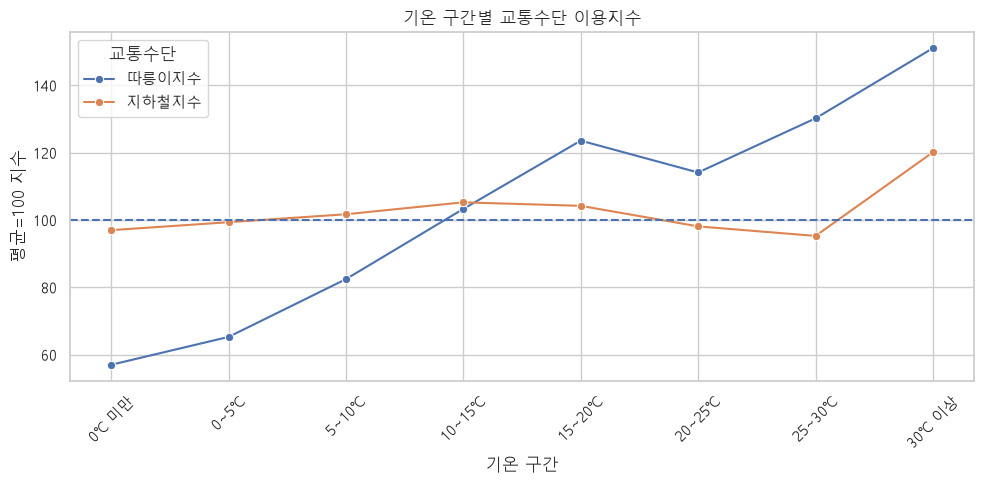

In [38]:
temp_index = temp_summary.melt(
    id_vars=['기온구간_탐색', '관측수'],
    value_vars=['따릉이지수', '지하철지수'],
    var_name='교통수단',
    value_name='이용지수'
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=temp_index,
    x='기온구간_탐색',
    y='이용지수',
    hue='교통수단',
    marker='o'
)

plt.axhline(100, linestyle='--')

plt.title('기온 구간별 교통수단 이용지수')
plt.xlabel('기온 구간')
plt.ylabel('평균=100 지수')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

일별 데이터로 한번 더 확인

In [39]:
daily = (
    analysis_df
    .groupby('날짜')
    .agg(
        평균기온=('기온(°C)', 'mean'),
        총따릉이=('따릉이대여건수', 'sum'),
        총지하철=('지하철승차인원', 'sum')
    )
    .reset_index()
)

daily.head()

,날짜,평균기온,총따릉이,총지하철
0,2025-03-04,2.477778,48302,4735238.0
1,2025-03-05,5.494444,85109,4991261.0
2,2025-03-06,5.822222,89896,5075082.0
3,2025-03-07,6.300000,92997,5235135.0
4,2025-03-10,9.227778,99341,4974804.0


기온 vs 일일 따릉이

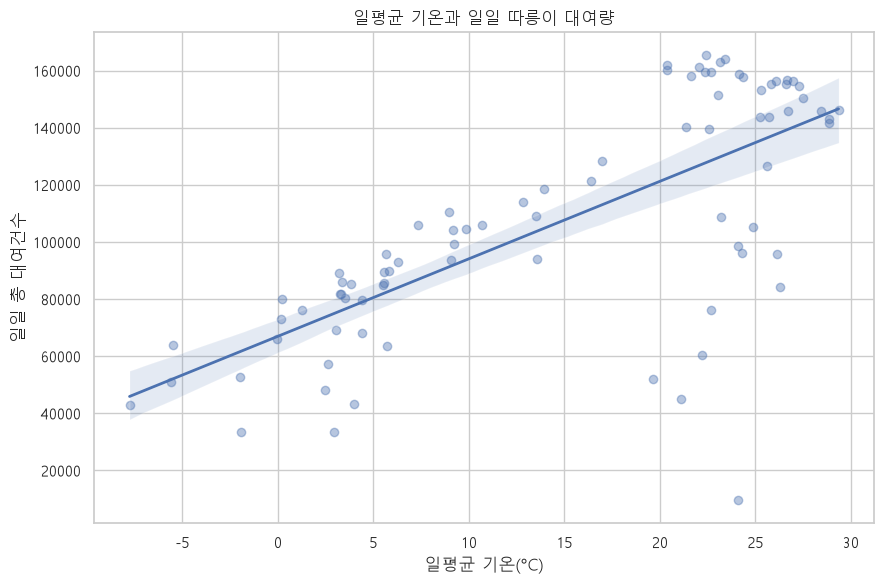

In [40]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=daily,
    x='평균기온',
    y='총따릉이',
    scatter_kws={'alpha': 0.4},
    line_kws={'linewidth': 2}
)

plt.title('일평균 기온과 일일 따릉이 대여량')
plt.xlabel('일평균 기온(°C)')
plt.ylabel('일일 총 대여건수')

plt.tight_layout()
plt.show()

기온 vs 일일 지하철

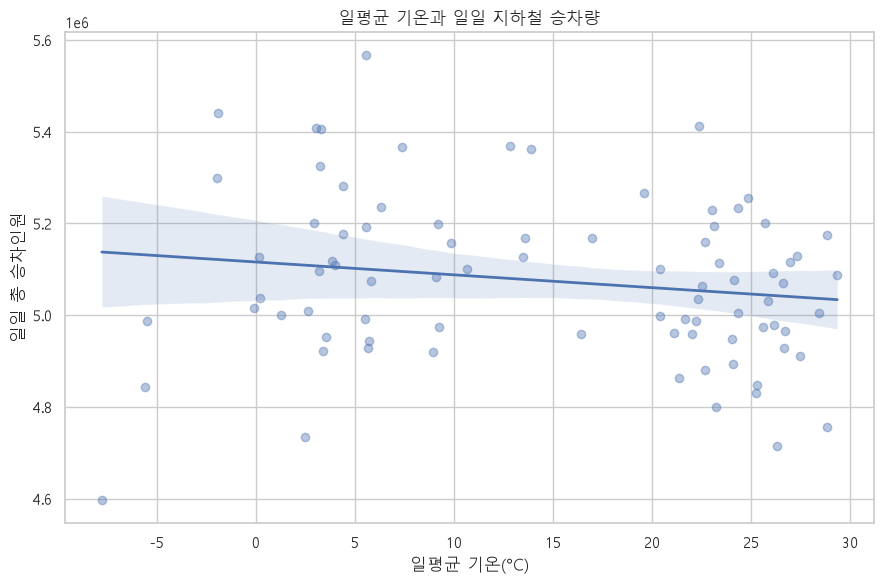

In [41]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=daily,
    x='평균기온',
    y='총지하철',
    scatter_kws={'alpha': 0.4},
    line_kws={'linewidth': 2}
)

plt.title('일평균 기온과 일일 지하철 승차량')
plt.xlabel('일평균 기온(°C)')
plt.ylabel('일일 총 승차인원')

plt.tight_layout()
plt.show()

일별 상관관계

In [42]:
print('===== 일별 Pearson =====')
print(
    daily[
        ['평균기온', '총따릉이', '총지하철']
    ].corr(method='pearson')
)

print('\n===== 일별 Spearman =====')
print(
    daily[
        ['평균기온', '총따릉이', '총지하철']
    ].corr(method='spearman')
)

===== 일별 Pearson =====
          평균기온      총따릉이      총지하철
평균기온  1.000000  0.715205 -0.165799
총따릉이  0.715205  1.000000 -0.010066
총지하철 -0.165799 -0.010066  1.000000

===== 일별 Spearman =====
          평균기온      총따릉이      총지하철
평균기온  1.000000  0.703270 -0.181689
총따릉이  0.703270  1.000000  0.010222
총지하철 -0.181689  0.010222  1.000000


# 월 x 시간대 히트맵
- 따릉이

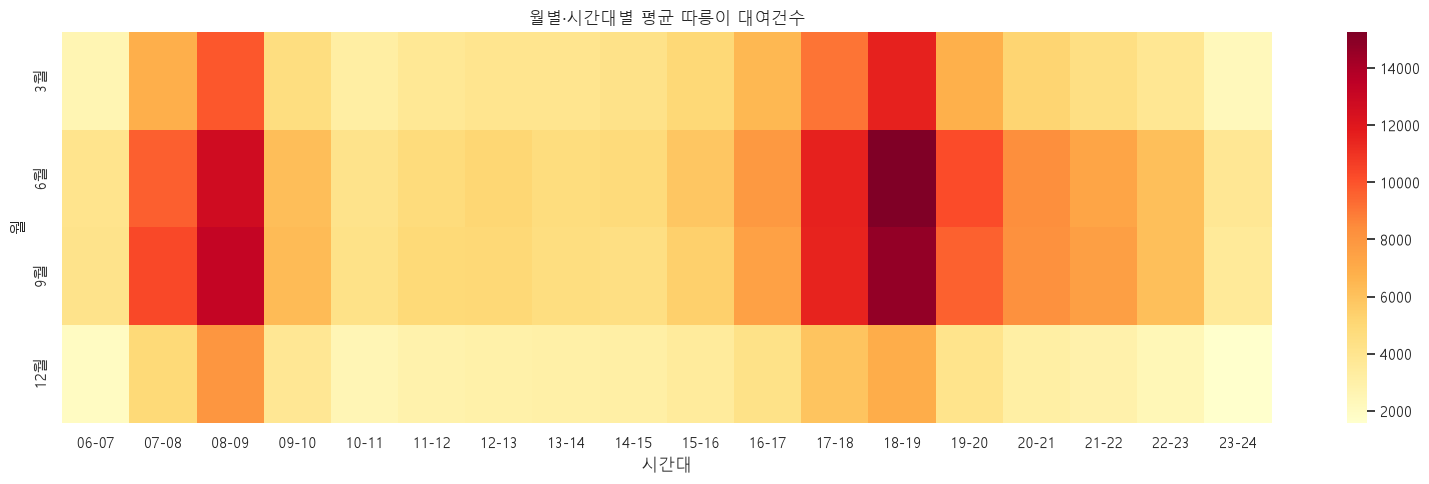

In [43]:
heat_bicycle = (
    analysis_df
    .pivot_table(
        index='월명',
        columns='시간대',
        values='따릉이대여건수',
        aggfunc='mean'
    )
    .reindex(['3월', '6월', '9월', '12월'])
    .reindex(columns=hour_order)
)

plt.figure(figsize=(16, 5))

sns.heatmap(
    heat_bicycle,
    annot=False,
    cmap='YlOrRd'
)

plt.title('월별·시간대별 평균 따릉이 대여건수')
plt.xlabel('시간대')
plt.ylabel('월')

plt.tight_layout()
plt.show()

- 지하철

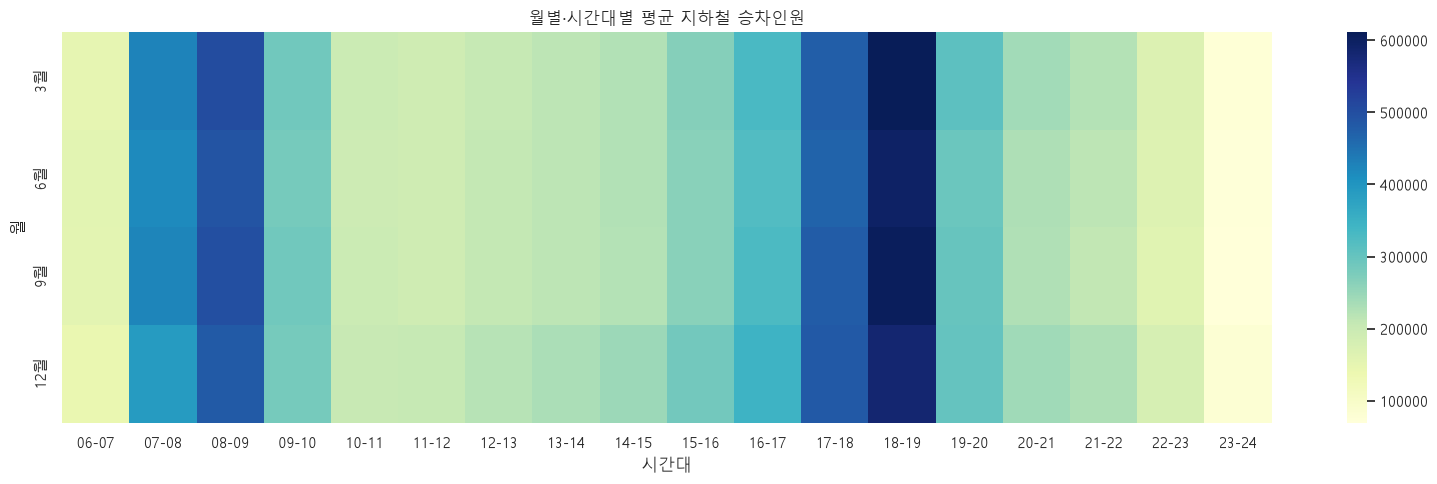

In [44]:
heat_subway = (
    analysis_df
    .pivot_table(
        index='월명',
        columns='시간대',
        values='지하철승차인원',
        aggfunc='mean'
    )
    .reindex(['3월', '6월', '9월', '12월'])
    .reindex(columns=hour_order)
)

plt.figure(figsize=(16, 5))

sns.heatmap(
    heat_subway,
    annot=False,
    cmap='YlGnBu'
)

plt.title('월별·시간대별 평균 지하철 승차인원')
plt.xlabel('시간대')
plt.ylabel('월')

plt.tight_layout()
plt.show()

# 월별 상관계수
- 민감도가 계절별로 약하고 강하고 차이가 나면 까다로워짐?

In [45]:
month_corr = []

for month, group in analysis_df.groupby('월', sort=True):
    month_corr.append({
        '월': month,
        '따릉이_Pearson': group['기온(°C)'].corr(
            group['따릉이대여건수'],
            method='pearson'
        ),
        '따릉이_Spearman': group['기온(°C)'].corr(
            group['따릉이대여건수'],
            method='spearman'
        ),
        '지하철_Pearson': group['기온(°C)'].corr(
            group['지하철승차인원'],
            method='pearson'
        ),
        '지하철_Spearman': group['기온(°C)'].corr(
            group['지하철승차인원'],
            method='spearman'
        ),
        '관측수': len(group)
    })

month_corr = pd.DataFrame(month_corr)

month_corr

,월,따릉이_Pearson,따릉이_Spearman,지하철_Pearson,지하철_Spearman,관측수
0,3,0.335016,0.388306,0.066205,0.139086,360
1,6,0.155051,0.194027,0.097731,0.174924,342
2,9,0.105573,0.103516,0.056432,0.082506,396
3,12,0.219701,0.314645,0.093700,0.139265,396


# 핵심 요약

In [ ]:
print('==============================')
print('EDA 핵심 요약')
print('==============================')

print('\n[분석 데이터]')
print(f'전체 행: {len(df):,}')
print(f'평일·비공휴일: {len(analysis_df):,}')
print(f'날짜 수: {analysis_df["날짜"].nunique():,}')

print('\n[기온]')
print(analysis_df['기온(°C)'].describe())

print('\n[따릉이]')
print(analysis_df['따릉이대여건수'].describe())

print('\n[지하철]')
print(analysis_df['지하철승차인원'].describe())

print('\n[전체 상관 - Pearson]')
print(
    analysis_df[
        ['기온(°C)', '따릉이대여건수', '지하철승차인원']
    ].corr(method='pearson')
)

print('\n[전체 상관 - Spearman]')
print(
    analysis_df[
        ['기온(°C)', '따릉이대여건수', '지하철승차인원']
    ].corr(method='spearman')
)

print('\n[시간대 통제 후 상관]')
print(
    within_hour[
        ['기온편차', '따릉이편차', '지하철편차']
    ].corr(method='pearson')
)

print('\n[월별 상관]')
print(month_corr)

EDA 핵심 요약

[분석 데이터]
전체 행: 2,196
평일·비공휴일: 1,494
날짜 수: 83

[기온]
count    1494.000000
mean       14.674096
std        10.960095
min       -11.800000
25%         4.400000
50%        17.900000
75%        24.000000
max        33.600000
Name: 기온(°C), dtype: float64

[따릉이]
count     1494.000000
mean      5933.419009
std       3815.027594
min        102.000000
25%       3391.250000
50%       4964.500000
75%       7695.750000
max      19943.000000
Name: 따릉이대여건수, dtype: float64

[지하철]
count      1494.000000
mean     281945.211513
std      132248.287337
min       51115.000000
25%      199355.500000
50%      237287.000000
75%      329742.000000
max      632005.000000
Name: 지하철승차인원, dtype: float64

[전체 상관 - Pearson]
           기온(°C)   따릉이대여건수   지하철승차인원
기온(°C)   1.000000  0.423440  0.012718
따릉이대여건수  0.423440  1.000000  0.652512
지하철승차인원  0.012718  0.652512  1.000000

[전체 상관 - Spearman]
           기온(°C)   따릉이대여건수   지하철승차인원
기온(°C)   1.000000  0.462517  0.015601
따릉이대여건수  0.462517  1.000000  0.572017
지하